In [16]:
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np


In [6]:
ds = xr.open_zarr("/Users/ivanr/Developer/ai-vineyard-productivity/agrixel-fair-dockerV2/data/output/files/SENTINEL-2/cube.zarr", consolidated=False)
ds['variable'] = ds['variable'].astype('str')
print(ds)

<xarray.Dataset> Size: 9MB
Dimensions:   (time: 2, variable: 3, y: 570, x: 628)
Coordinates:
  * time      (time) datetime64[ns] 16B 2024-05-09T10:50:31 2024-05-09T10:50:31
  * variable  (variable) <U4 48B 'B04' 'B08' 'NDVI'
  * y         (y) float64 5kB 5.12e+06 5.12e+06 5.12e+06 ... 5.115e+06 5.115e+06
  * x         (x) float64 5kB 1.068e+05 1.069e+05 ... 1.131e+05 1.131e+05
Data variables:
    data      (time, variable, y, x) float32 9MB ...
Attributes:
    crs:        EPSG:3857
    res_m:      10.0
    height:     570
    width:      628
    transform:  [10.0, 0.0, 106841.87405178921, 0.0, -10.0, 5120250.461740777]
    variables:  ['B04', 'B08', 'NDVI']
    time_iso:   ['2024-05-09T10:50:31Z', '2024-05-09T10:50:31Z']


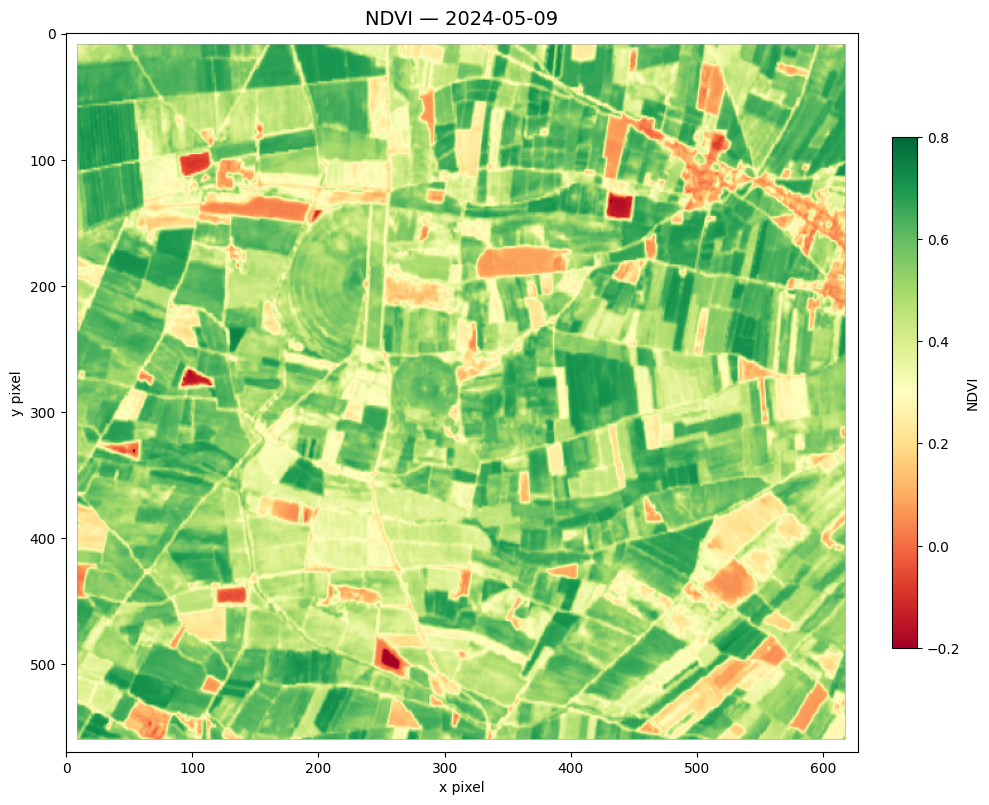

In [18]:

# Plot NDVI
ndvi = ds['data'].sel(variable='NDVI').isel(time=0).values  # shape (y, x)

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(
    ndvi,
    cmap='RdYlGn',
    vmin=-0.2,
    vmax=0.8,
    origin='upper',
)
plt.colorbar(im, ax=ax, label='NDVI', fraction=0.03, pad=0.04)
ax.set_title('NDVI — 2024-05-09', fontsize=14)
ax.set_xlabel('x pixel')
ax.set_ylabel('y pixel')
plt.tight_layout()
plt.show()
